In [33]:
trace_file = 'experiments_mock/Qwen-7B_constant_sharegpt_code:azure_code_23_3978:4500_anytime_0.0/slosserve-edf_auto_scaling_resch-all_chat-1.0_1.0_8_anytime_3.0_0.025.reqs.jsonl'
events_file = 'experiments_mock/Qwen-7B_constant_sharegpt_code:azure_code_23_3978:4500_anytime_0.0/slosserve-edf_auto_scaling_resch-all_chat-1.0_1.0_8_anytime_3.0_0.025.events.jsonl'

In [2]:
import json 

In [4]:
with open(trace_file, 'r') as f:
    reqs = json.load(f)

In [10]:
max_tpots = [max(req['tpot_laxities']) for req in reqs]

In [11]:
import matplotlib.pyplot as plt

In [ ]:
sum(max_tpot < 0.1 for max_tpot in max_tpots) / len(max_tpots)

0.9386973180076629

In [20]:
req = next(req for req in reqs if max(req['tpot_laxities']) > 0)

In [28]:
idx = next(i for i, tpot_laxity in enumerate(req['tpot_laxities']) if tpot_laxity > 0)

[{'batch_id': 15689,
  'num_scheduled_tokens': 1,
  'elapsed': 0.0319361686706543,
  'timestamp': 51.18210082054138,
  'device_id': 0},
 {'batch_id': 15690,
  'num_scheduled_tokens': 1,
  'elapsed': 0.03203082084655762,
  'timestamp': 51.21413784027099,
  'device_id': 0},
 {'batch_id': 15691,
  'num_scheduled_tokens': 1,
  'elapsed': 0.05372285842895508,
  'timestamp': 51.26786737442016,
  'device_id': 0},
 {'batch_id': 15692,
  'num_scheduled_tokens': 1,
  'elapsed': 0.038843393325805664,
  'timestamp': 51.306717443466184,
  'device_id': 0},
 {'batch_id': 15693,
  'num_scheduled_tokens': 1,
  'elapsed': 0.06791377067565918,
  'timestamp': 51.37464027404785,
  'device_id': 0},
 {'batch_id': 15694,
  'num_scheduled_tokens': 1,
  'elapsed': 0.04254651069641113,
  'timestamp': 51.41719822883606,
  'device_id': 0},
 {'batch_id': 15695,
  'num_scheduled_tokens': 1,
  'elapsed': 0.0313258171081543,
  'timestamp': 51.44853262901306,
  'device_id': 0},
 {'batch_id': 15696,
  'num_scheduled_tok

In [34]:
with open(events_file, 'r') as f:
    events = json.load(f)

In [36]:
batches = [event for event in events if event['event_type'] == 'batch']

In [40]:
batch_ids = set(batch['batch_id'] for batch in req['schedules'][idx - 10:idx + 10])

In [ ]:
batches_subset = [batch for batch in batches if batch['batch_id'] in batch_ids]

[{'event_type': 'batch',
  'batch_id': 12986,
  'timestamp': 0.49892544746398926,
  'elapsed': 0.01516866683959961,
  'req_ids': ['1'],
  'num_computed_tokens': [0],
  'num_scheduled_tokens': {'1': 29},
  'scheduling_overhead': 0.0003323554992675781,
  'between_batch_time': 0.01516866683959961,
  'output_processing_elapsed': 1.71661376953125e-05,
  'estimated_time': 0,
  'device_id': 0},
 {'event_type': 'batch',
  'batch_id': 12987,
  'timestamp': 0.5204257965087891,
  'elapsed': 0.021492719650268555,
  'req_ids': ['5', '3', '1'],
  'num_computed_tokens': [0, 0, 29],
  'num_scheduled_tokens': {'1': 1, '5': 42, '3': 74},
  'scheduling_overhead': 0.0009329319000244141,
  'between_batch_time': 0.021492719650268555,
  'output_processing_elapsed': 1.7642974853515625e-05,
  'estimated_time': 0,
  'device_id': 0},
 {'event_type': 'batch',
  'batch_id': 12988,
  'timestamp': 0.5415668487548828,
  'elapsed': 0.021132946014404297,
  'req_ids': ['6', '2', '5', '3'],
  'num_computed_tokens': [0, 0

In [32]:
import json

In [33]:
filename = 'experiments_mock/Qwen-7B_constant_azure_code_23:azure_code_23_0:1000_arrival_0.0/slosserve-edf_slosserve_1.0_6_arrival_5.0_0.05.events.jsonl'
req_filename = 'experiments_mock/Qwen-7B_constant_azure_code_23:azure_code_23_0:1000_arrival_0.0/slosserve-edf_slosserve_1.0_6_arrival_5.0_0.05.reqs.jsonl'
filename = 'experiments_mock/Qwen-7B_constant_azure_code_23:azure_code_23_0:1000_arrival_0.0/atfc_slosserve_1.0_6_arrival_5.0_0.05.events.jsonl'
req_filename = 'experiments_mock/Qwen-7B_constant_azure_code_23:azure_code_23_0:1000_arrival_0.0/atfc_slosserve_1.0_6_arrival_5.0_0.05.reqs.jsonl'
file_prefix = 'experiments_mock/Qwen-7B_constant_azure_code_23:azure_code_23_0:500_arrival_0.0/atfc_slosserve_1.0_6_arrival_5.0_0.05'
file_prefix = 'experiments_mock/Qwen-7B_constant_azure_code_23:azure_code_23_0:500_arrival_0.0/atfc_slosserve_1.0_6_arrival_5.0_0.05'
file_prefix = 'experiments_emulation/Qwen-7B_constant_azure_code_23:azure_code_23_t0:600_arrival_0.0/atfc_slosserve_2_0.5_8_arrival_5.0_0.05_reject'
filename = f'{file_prefix}.events.jsonl'
req_filename = f'{file_prefix}.reqs.jsonl'
with open(filename, 'r') as f:
    data = json.load(f)
with open(req_filename, 'r') as f:
    req_data = json.load(f)

In [34]:
batches = [x for x in data if x['event_type'] == 'batch']

In [35]:
batches = [(b['between_batch_time'] - b['estimated_time'], b) for b in batches]

In [36]:
batches = sorted(batches, reverse = True, key = lambda x: x[0])

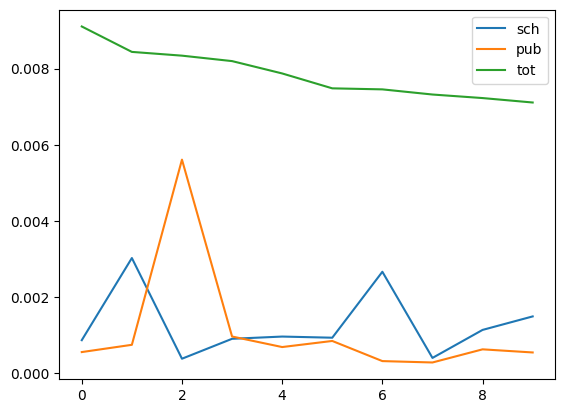

In [37]:
top_batches = batches[:10]
scheduling_overheads = [b[1]['scheduling_overhead'] for b in top_batches]
publish_overheads = [b[1]['publish_overhead'] for b in top_batches]
total_overhead = [b[0] for b in top_batches]
import matplotlib.pyplot as plt
fig, ax = plt.subplots()
for label, overheads in [
    ('sch', scheduling_overheads),
    ('pub', publish_overheads),
    ('tot', total_overhead)
]:
    ax.plot(overheads, label = label)
ax.legend()

In [38]:
[x['event_type'] for x in req_data[0]['events']], req_data[0]['events'], req_data[0]['slo_violation']

(['global_arrival',
  'arrival-router',
  'router_decision',
  'dispatch',
  'arrival',
  'finish'],
 [{'event_type': 'global_arrival',
   'timestamp': 0.01848316192626953,
   'device_id': 0,
   'extra_args': {},
   'request_id': '0'},
  {'event_type': 'arrival-router',
   'timestamp': 0.18118715286254883,
   'device_id': -1,
   'extra_args': {},
   'request_id': '0',
   'prefill_ddl': 0.35660672187805176,
   'profit': 1.0,
   'prompt_tokens': 217,
   'max_tokens': 9,
   'zero_load_ttft': 0.0250839},
  {'event_type': 'router_decision',
   'timestamp': 0.19341564178466797,
   'device_id': -1,
   'extra_args': {},
   'request_id': '0',
   'prefill_device_id': 0,
   'decode_device_id': 0},
  {'event_type': 'dispatch',
   'timestamp': 0.1967637538909912,
   'device_id': -1,
   'extra_args': {},
   'type': 'both',
   'request_id': '0',
   'prefill_device_id': 0,
   'decode_device_id': 0},
  {'event_type': 'arrival',
   'timestamp': 0.2018890380859375,
   'device_id': 0,
   'extra_args': {},

In [39]:
req_data[0].keys()

dict_keys(['req_id', 'prompt_tokens', 'num_cached_tokens', 'arrival_time', 'engine_arrival_time', 'profit', 'schedules', 'events', 'timestamps', 'output_tokens', 'prefill_device_id', 'decode_device_id', 'cache_hit_rate', 'prefill_ddl', 'ttft_normalized_laxity', 'tpot_laxities', 'expected_finish_time', 'finish_reason', 'slo_violation', 'kv_xfer_delay', 'zero_load_ttft'])

In [40]:
from collections import defaultdict
import pandas as pd

In [41]:
slo_violated_to_arrive_finish_pairs = defaultdict(list)
slo_violated_to_finish_rescheduling_pairs = defaultdict(list)
slo_attained_to_arrive_finish_pairs = defaultdict(list)

In [42]:
violation_reasons = defaultdict(int)
for req in req_data:

    violation_reasons[req['slo_violation']] += 1
    for eid, e in enumerate(req['events']):
        if e['event_type'] == 'arrival':
            i = eid + 1
            while i < len(req['events']) and req['events'][i]['event_type'] != 'finish':
                i += 1 
            if not i < len(req['events']): continue
            next_e = req['events'][i]
            # assert next_e['event_type'] == 'finish'
            if req['slo_violation'] != 'none':
                slo_violated_to_arrive_finish_pairs[req['req_id']].append((e['timestamp'], next_e['timestamp'], e['device_id']))
            else:
                slo_attained_to_arrive_finish_pairs[req['req_id']].append((e['timestamp'], next_e['timestamp'], e['device_id']))
        if e['event_type'] == 'finish' and next_e['event_type'] == 'rescheduling':
            slo_violated_to_finish_rescheduling_pairs[req['req_id']].append(next_e['timestamp'] - e['timestamp'])
violation_reasons

defaultdict(int, {'none': 73, 'router_rejection': 1409})

In [43]:
top_batches = batches[:10]

n_overlap = 0
for req, arrive_finish_pairs in slo_violated_to_arrive_finish_pairs.items():
    is_overlap = False
    for arrive, finish, device in arrive_finish_pairs:
        for _, b in top_batches:
            if (b['device_id'] == device) and (arrive < b['timestamp'] < finish):
                is_overlap = True 
    n_overlap += is_overlap
n_overlap / len(slo_violated_to_arrive_finish_pairs), n_overlap, len(slo_violated_to_arrive_finish_pairs)

(0.0, 0, 1409)

(count       0
 unique      0
 top       NaN
 freq      NaN
 dtype: object,
 (array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]),
  array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
  <BarContainer object of 10 artists>))

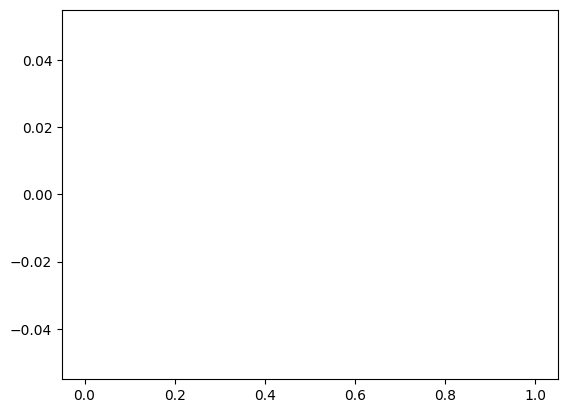

In [44]:
violated_reqs = [req for req in req_data if req['slo_violation'] == 'ttft']
laxities = [x['ttft_normalized_laxity'] for x in violated_reqs]
pd.Series(laxities).describe(percentiles=[0.50, 0.60, 0.70, 0.80, 0.90, 0.95, 0.99]), plt.hist(laxities)

In [45]:
rejected_reqs = [req for req in req_data if 'reject' in req['slo_violation']]
results = []
for req in rejected_reqs:
    breakdown = []
    acc = 0
    for e, next_e in zip(req['events'][1:], req['events'][2:]):
        gap = round(next_e['timestamp'] - e['timestamp'], 6)
        breakdown.append((e['event_type'] + '->' + next_e['event_type'], gap, acc + gap))
        acc += gap
    results.append((req['req_id'], req['prefill_ddl'] - req['arrival_time'], req['prompt_tokens'], breakdown))
results[0]
# TODO: visulize this for each request by having a bar graph, each entry is a request with a breakdown by time categories; also, add a mark for each request's req['prefill_ddl'] - req['arrival_time']

('69',
 0.39650440216064453,
 1084,
 [('arrival-router->router_decision', 0.002384, 0.002384),
  ('router_decision->dispatch', 0.004259, 0.006643),
  ('dispatch->arrival', 0.004858, 0.011501),
  ('arrival->finish', 0.001055, 0.012556000000000001),
  ('finish->rescheduling', 0.004281, 0.016837),
  ('rescheduling->router_decision', 0.004092, 0.020929000000000003),
  ('router_decision->dispatch', 0.003994, 0.024923000000000004),
  ('dispatch->arrival', 0.003965, 0.028888000000000004),
  ('arrival->finish', 0.001127, 0.030015000000000003),
  ('finish->rescheduling', 0.004696, 0.034711000000000006),
  ('rescheduling->router_decision', 0.001076, 0.035787000000000006),
  ('router_decision->dispatch', 0.004024, 0.039811000000000006),
  ('dispatch->arrival', 0.004669, 0.044480000000000006),
  ('arrival->finish', 0.001103, 0.045583000000000005),
  ('finish->rescheduling', 0.00485, 0.050433000000000006),
  ('rescheduling->finish', 0.005075, 0.055508)])

In [46]:
req_data[0]['schedules'], req_data[0]['prefill_device_id']

([{'batch_id': 1,
   'num_scheduled_tokens': 217,
   'elapsed': 0.030430316925048828,
   'timestamp': 0.2330317497253418,
   'device_id': 0},
  {'batch_id': 2,
   'num_scheduled_tokens': 1,
   'elapsed': 0.016954421997070312,
   'timestamp': 0.2500035762786865,
   'device_id': 0},
  {'batch_id': 3,
   'num_scheduled_tokens': 1,
   'elapsed': 0.01821446418762207,
   'timestamp': 0.2682301998138428,
   'device_id': 0},
  {'batch_id': 4,
   'num_scheduled_tokens': 1,
   'elapsed': 0.12366390228271484,
   'timestamp': 0.36823019981384275,
   'device_id': 0},
  {'batch_id': 5,
   'num_scheduled_tokens': 1,
   'elapsed': 0.016661405563354492,
   'timestamp': 0.3849035263061523,
   'device_id': 0},
  {'batch_id': 6,
   'num_scheduled_tokens': 1,
   'elapsed': 0.01668715476989746,
   'timestamp': 0.40159783363342283,
   'device_id': 0},
  {'batch_id': 7,
   'num_scheduled_tokens': 1,
   'elapsed': 0.01671290397644043,
   'timestamp': 0.4183181285858154,
   'device_id': 0},
  {'batch_id': 8,
  

In [47]:
batches = {(x['batch_id'], x['device_id']): x for x in data if x['event_type'] == 'batch'}
bid2batch_start_time = {}
for b in batches.values():
    bid2batch_start_time[(b['batch_id'], b['device_id'])] =  (b['timestamp'] - b['elapsed'])
batches[0], bid2batch_start_time[(1,0)]

KeyError: 0

In [48]:
slo_violate_reqs = [req for req in req_data if req['slo_violation'] == 'ttft']
results = []
for req in slo_violate_reqs:
    prompt_tokens = req['prompt_tokens']
    breakdown = []
    acc = 0
    last_timestamp = None
    for e, next_e in zip(req['events'][1:], req['events'][2:]):
        gap = round(next_e['timestamp'] - e['timestamp'], 6)
        last_timestamp = next_e['timestamp']
        breakdown.append((e['event_type'] + '->' + next_e['event_type'], gap, acc + gap))
        acc += gap
        if next_e['event_type'] == 'arrival' and next_e['device_id'] == req['prefill_device_id']:
            break
    first_sch = req['schedules'][0]
    batch_events = [('B0_start', first_sch['timestamp'] - first_sch['elapsed'])]
    key = (first_sch['batch_id'] - 1, req['prefill_device_id'])
    if key in batches:
        last_batch = batches[key]
        batch_events.extend([
            ('LB-start', last_batch['timestamp'] - last_batch['elapsed']),
            ('LB-schedule', last_batch['timestamp'] - last_batch['elapsed'] + last_batch['extra_args']['to_schedule']),
            ('LB-launch', last_batch['timestamp'] - last_batch['elapsed'] + last_batch['extra_args']['to_launch']),
            ('LB-finish', last_batch['timestamp'] - last_batch['elapsed'] + last_batch['extra_args']['to_finish']),
            ('LB-est_finish', last_batch['timestamp'] - last_batch['elapsed'] + last_batch['extra_args']['to_est_finish']),
        ])
    
    batch_events = sorted(batch_events, key = lambda x: x[1])
    last_event = 'arrival'
    for event_name, timestamp in batch_events:
        if timestamp < last_timestamp: continue
        gap = timestamp - last_timestamp
        breakdown.append((f'{last_event} -> {event_name}', gap, acc + gap))
        last_event = event_name 
        last_timestamp = timestamp
    
    # gap = bid2batch_start_time[(req['schedules'][0]['batch_id'], req['prefill_device_id'])] - last_timestamp
    # last_timestamp = bid2batch_start_time[(req['schedules'][0]['batch_id'], req['prefill_device_id'])]
    # breakdown.append((f'{last_event} -> B0_start', gap, gap + acc))
    # acc += gap 
    # last_event = 'B0_start'
    
    for bid, b in enumerate(req['schedules']):
        gap = b['timestamp'] - last_timestamp
        last_timestamp = b['timestamp']
        breakdown.append((f'{last_event}->B{bid}', gap, acc + gap))
        acc += gap
        last_event = f'B{bid}'
        prompt_tokens -= b['num_scheduled_tokens']
        if prompt_tokens <= 0: break
    results.append((req['req_id'], req['prefill_ddl'] - req['arrival_time'], req['prompt_tokens'], breakdown))
results[0]

IndexError: list index out of range

In [49]:
import matplotlib.pyplot as plt

def plot_reject_breakdowns(results, max_reqs=None, sort_by="ddl", title=None):
    """
    Stacked horizontal bars per request:
      - each segment = time gap between events
      - vertical marker = ddl_budget (prefill_ddl - arrival_time)

    sort_by: "ddl" | "total" | "prompt" | None
    """
    if not results:
        raise ValueError("results is empty")

    # Optionally sort
    if sort_by == "ddl":
        results = sorted(results, key=lambda x: x[0])
    elif sort_by == "total":
        results = sorted(results, key=lambda x: sum(seg[1] for seg in x[2]))
    elif sort_by == "prompt":
        results = sorted(results, key=lambda x: x[1])

    if max_reqs is not None:
        results = results[:max_reqs]

    # Build a stable category list (preserve first-seen order)
    categories = []
    cat_set = set()
    for req_id, ddl_budget, prompt_tokens, breakdown in results:
        for label, gap, _ in breakdown:
            label = label.replace('_mux', 'mux')
            if label not in cat_set:
                cat_set.add(label)
                categories.append(label)

    # Matrix of durations: rows=requests, cols=categories
    durations = []
    ddl_budgets = []
    prompts = []
    totals = []
    req_ids = []
    
    print('categories', categories)

    for req_id, ddl_budget, prompt_tokens, breakdown in results:
        row = {c: 0.0 for c in categories}
        total = 0.0
        for label, gap, _ in breakdown:
            label = label.replace('_mux', 'mux')
            row[label] += float(gap)
            total += float(gap)
        print('req_id', req_id, row)
        durations.append([row[c] for c in categories])
        ddl_budgets.append(float(ddl_budget))
        prompts.append(int(prompt_tokens))
        totals.append(total)
        req_ids.append(req_id)

    n = len(results)
    y = list(range(n))

    # Plot
    fig_h = max(4, 0.35 * n)  # scale height with number of reqs
    fig, ax = plt.subplots(figsize=(12, fig_h))

    left = [0.0] * n
    for j, cat in enumerate(categories):
        seg = [durations[i][j] for i in range(n)]
        ax.barh(y, seg, left=left, label=cat)
        left = [left[i] + seg[i] for i in range(n)]

    # DDL markers (one per request)
    # Using scatter with "|" marker makes it easy to see.
    ax.scatter(ddl_budgets, y, marker="|", s=300, color="black", linewidths=2, label="DDL budget")

    # Y labels: include prompt tokens + total
    ylabels = [f"req {req_ids[i]} | prompt={prompts[i]} | total={totals[i]:.3f}s | bgt={ddl_budgets[i]:.3f}" for i in range(n)]
    ax.set_yticks(y)
    ax.set_yticklabels(ylabels)

    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Rejected requests")
    ax.invert_yaxis()  # top-to-bottom

    if title is None:
        title = "Rejected request timeline breakdowns (stacked) with DDL budget markers"
    ax.set_title(title)

    # Helpful grid
    ax.grid(True, axis="x", linestyle="--", linewidth=0.5, alpha=0.5)

    # Legend: put outside if many categories
    ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)

    plt.tight_layout()
    return fig, ax

# Example usage:
fig, ax = plot_reject_breakdowns(results, max_reqs=50, sort_by="ddl")
plt.show()

ValueError: results is empty

In [ ]:

{'arrival-router->router_decision': 0.001441, 'router_decision->dispatch': 0.006315, 'dispatch->arrive_decode_stream': 0.005794, 'arrive_decode_stream->arrive_mock_engine': 4.4e-05, 'arrive_mock_engine->arrival': 0.011048, 'arrival -> LB-est_finish': 0.0, 'LB-est_finish -> LB-finish': 0.0, 'LB-finish -> B0_start': 0.0, 'B0_start->B0': 0.40134692192077637, 'arrival->finish': 0.0, 'finish->mock_engine_get_response': 0.0, 'mock_engine_get_response->get_decode_stream_response': 0.0, 'get_decode_stream_response->decode_stream_put': 0.0, 'decode_stream_put->mux_read': 0.0, 'mux_read->mux_push': 0.0, 'mux_push->rescheduling': 0.0, 'rescheduling->router_decision': 0.0, 'arrival -> LB-finish': 0.0, 'LB-finish -> LB-est_finish': 0.00011897087097167969, 'LB-est_finish -> B0_start': 0.0023145675659179688, 'arrival -> LB-start': 2.1908152103424072, 'LB-start -> LB-schedule': 1.4781951904296875e-05, 'LB-schedule -> LB-launch': 0.0006666183471679688, 'LB-launch -> LB-finish': 0.014108657836914062, 'B0->B1': 0.0, 'B1->B2': 0.0, 'B2->B3': 0.0, 'B3->B4': 0.0, 'B4->B5': 0.0, 'B5->B6': 0.0, 'B6->B7': 0.0, 'B7->B8': 0.0, 'B8->B9': 0.0, 'arrival->B0': 0.0, 'LB-launch -> LB-est_finish': 0.0, 'B9->B10': 0.0}


In [17]:
batch_planners = [e for e in data if e['event_type'] ==  "batch_planner_batch_commit"]
batch_planners[0]

{'event_type': 'batch_planner_batch_commit',
 'timestamp': 0.5536074638366699,
 'extra_args': {'estimated_finish_time': 1771780507.389579,
  'slack': 0.0027387142181396484,
  'start_time': None},
 'device_id': 0}

(count    6759.000000
 mean        0.004037
 std         0.005706
 min        -0.396924
 25%         0.003958
 50%         0.004278
 75%         0.004379
 max         0.005355
 dtype: float64,
 (array([1.000e+00, 0.000e+00, 0.000e+00, 1.000e+00, 0.000e+00, 0.000e+00,
         0.000e+00, 0.000e+00, 0.000e+00, 6.757e+03]),
  array([-0.39692402, -0.35669608, -0.31646814, -0.27624021, -0.23601227,
         -0.19578433, -0.15555639, -0.11532845, -0.07510052, -0.03487258,
          0.00535536]),
  <BarContainer object of 10 artists>),
 6759,
 6746,
 [-0.0012829303741455078,
  -0.0006778240203857422,
  -0.0006608963012695312,
  -0.0001990795135498047,
  -0.0013256072998046875,
  -6.961822509765625e-05,
  -9.703636169433594e-05,
  -0.23615002632141113,
  -0.00033664703369140625,
  -0.0018870830535888672,
  -0.0005846023559570312,
  -0.00020766258239746094,
  -0.3969240188598633])

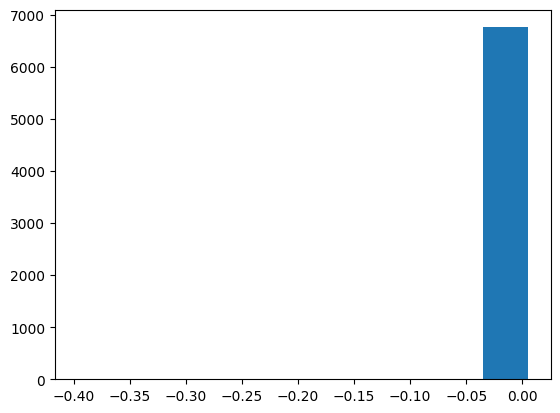

In [22]:
slacks = [e['extra_args']['slack'] for e in batch_planners]
pd.Series(slacks).describe(), plt.hist(slacks), len(slacks), sum(x>=0 for x in slacks), [x for x in slacks if x < 0]

(count    389.000000
 mean       1.174807
 std        0.502861
 min        1.000000
 25%        1.000000
 50%        1.000000
 75%        1.000000
 max        5.000000
 dtype: float64,
 count    108.000000
 mean       1.222222
 std        0.499221
 min        1.000000
 25%        1.000000
 50%        1.000000
 75%        1.000000
 max        3.000000
 dtype: float64)

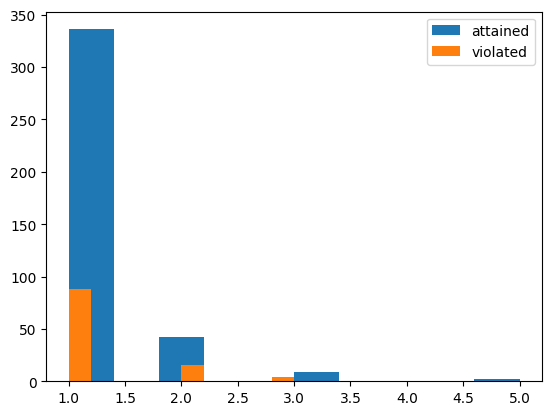

In [16]:
attained_lens = [len(x) for x in slo_attained_to_arrive_finish_pairs.values()]
violated_lens = [len(x) for x in slo_violated_to_arrive_finish_pairs.values()]
fig, ax = plt.subplots()
ax.hist(attained_lens, label = 'attained')
ax.hist(violated_lens, label = 'violated')
ax.legend()
pd.Series(attained_lens).describe(), pd.Series(violated_lens).describe()

In [188]:
trajectories = [[y[-1] for y in x] for x in slo_violated_to_arrive_finish_pairs.values()]
trajectories

[[0],
 [0],
 [0],
 [0],
 [0],
 [0],
 [0, 1],
 [0],
 [0],
 [0],
 [0, 1],
 [0, 2],
 [0],
 [0],
 [1],
 [2],
 [2, 3],
 [2, 3],
 [2],
 [2, 3],
 [2, 4],
 [2],
 [0],
 [0],
 [1],
 [1],
 [0],
 [2],
 [2, 3],
 [0, 2, 3],
 [1],
 [1],
 [3],
 [0],
 [1],
 [1],
 [1],
 [1],
 [0],
 [0],
 [1],
 [2],
 [2],
 [0],
 [0],
 [0],
 [0],
 [0],
 [0],
 [0],
 [0, 1],
 [0, 2],
 [0, 1],
 [0],
 [1],
 [2],
 [1],
 [1],
 [3],
 [1],
 [3],
 [3, 4, 5],
 [3],
 [3],
 [3],
 [3, 5],
 [3],
 [3],
 [2],
 [1],
 [1],
 [1],
 [1, 4],
 [1],
 [0],
 [1],
 [0],
 [2],
 [0],
 [0, 1],
 [0],
 [0, 1]]

(count    19.000000
 mean      0.030044
 std       0.007856
 min       0.018146
 25%       0.023548
 50%       0.029608
 75%       0.037764
 max       0.041466
 dtype: float64,
 (array([3., 2., 1., 1., 3., 1., 2., 0., 2., 4.]),
  array([0.0181458 , 0.0204778 , 0.02280979, 0.02514179, 0.02747378,
         0.02980578, 0.03213778, 0.03446977, 0.03680177, 0.03913376,
         0.04146576]),
  <BarContainer object of 10 artists>))

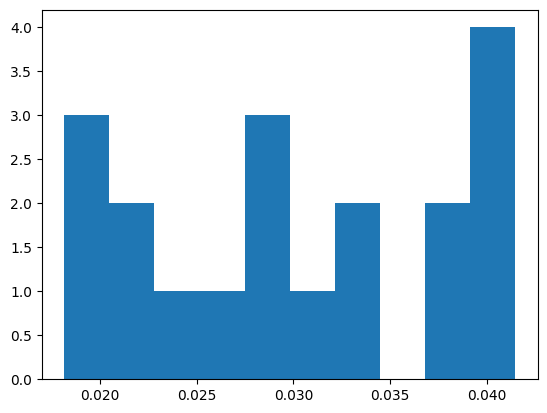

In [189]:
time_bewteen_arrives = []
for req, arrive_finish_pairs in slo_violated_to_arrive_finish_pairs.items():
    time_bewteen_arrives.extend(x[0] - y[0] for x, y in zip(arrive_finish_pairs[1:], arrive_finish_pairs))
pd.Series(time_bewteen_arrives).describe(), plt.hist(time_bewteen_arrives)

In [ ]:
top_batches = batches[:10]

n_overlap = 0
for req, arrive_finish_pairs in slo_violated_to_arrive_finish_pairs.items():
    is_overlap = False
    for arrive, finish, device in arrive_finish_pairs:
        for _, b in top_batches:
            if (b['device_id'] == device) and (arrive < b['timestamp']) and (b['timestamp'] < finish):
                is_overlap = True 
    n_overlap += is_overlap
n_overlap / len(slo_violated_to_arrive_finish_pairs), n_overlap, len(slo_violated_to_arrive_finish_pairs)

(0.0, 0, 82)

(count      82.000000
 mean     1189.207317
 std      1568.132047
 min        10.000000
 25%       153.250000
 50%       515.500000
 75%      1549.250000
 max      7436.000000
 dtype: float64,
 count     418.000000
 mean     2291.193780
 std      2064.783534
 min        14.000000
 25%       719.000000
 50%      1743.000000
 75%      3213.750000
 max      7437.000000
 dtype: float64)

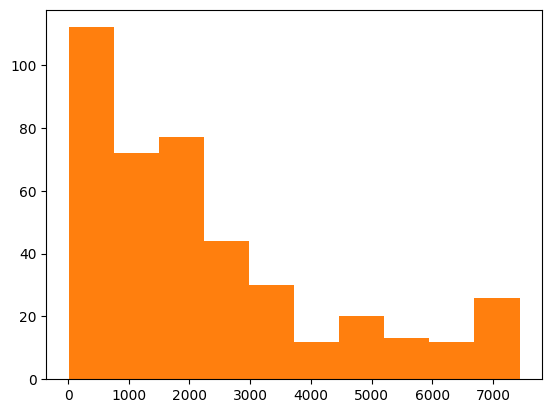

In [191]:
violated_reqs = [req for req in req_data if req['slo_violation'] != 'none']
attained_reqs = [req for req in req_data if req['slo_violation'] == 'none']
plt.hist([req['prompt_tokens'] for req in violated_reqs])
plt.hist([req['prompt_tokens'] for req in attained_reqs])
pd.Series([req['prompt_tokens'] for req in violated_reqs]).describe(), pd.Series([req['prompt_tokens'] for req in attained_reqs]).describe()

In [23]:
violated_reqs[5]

{'req_id': '89',
 'prompt_tokens': 204,
 'num_cached_tokens': 0,
 'arrival_time': 188.6897008419037,
 'engine_arrival_time': 188.7269208431244,
 'profit': 0,
 'schedules': [],
 'events': [{'event_type': 'global_arrival',
   'timestamp': 188.5438632965088,
   'device_id': 0,
   'request_id': '89'},
  {'event_type': 'arrival-router',
   'timestamp': 188.6897008419037,
   'device_id': -1,
   'request_id': '89',
   'prefill_ddl': 188.86180543899536,
   'profit': 1.0,
   'prompt_tokens': 204,
   'max_tokens': 63,
   'zero_load_ttft': 0.024420900000000002},
  {'event_type': 'router_decision',
   'timestamp': 188.69125866889954,
   'device_id': -1,
   'request_id': '89',
   'prefill_device_id': 0,
   'decode_device_id': 0},
  {'event_type': 'dispatch',
   'timestamp': 188.69679403305054,
   'device_id': -1,
   'type': 'both',
   'request_id': '89',
   'prefill_device_id': 0,
   'decode_device_id': 0},
  {'event_type': 'arrival',
   'timestamp': 188.7269208431244,
   'device_id': 0,
   'reques

In [2]:
import pandas as pd 
import math
import matplotlib.pyplot as plt


In [1]:

def plot(event_file):
    df = pd.read_json(event_file, lines=True)

    df['relative power'] = df['energy_est'] * df['load_scale']

    features = ['load_scale', 'n_device', 'ttft_slo_scale', 'slo_tpot']
    LABEL_MAP = {
        'atfc / slosserve_1_disagg_4': 'SLO Packer (Disagg)',
        'atfc / slosserve_2': 'SLO Packer (2, Colocated)',
        'atfc / slosserve_1': 'SLO Packer (1, Colocated)',
        'atfc / slosserve': 'SLO Packer (Colocated)',
        'atfc / round_robin': 'SLO Packer (Round Robin)',
        'atfc / slosserve_4': 'SLO Packer (4, Colocated)',
        'atfc / slosserve_5': 'SLO Packer (5, Colocated)',
        'sarathi+ / round_robin': 'vLLM+ (Colocated)',
        'sarathi+ / round_robin-1-disagg-4': 'vLLM + (Disagg)'
    }
    for feature in features:
        if len(df[feature].unique()) == 1:
            continue
        other_features = [f for f in features if f != feature]
        n_groups = len(df.groupby(other_features))
        ncols = min(3, n_groups)
        nrows = math.ceil(n_groups / ncols)
        for ylabel in ['relative power', 'slo_violation_rate']:
            fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows), squeeze=False)
            idx = 0
            for other_feature_values, group in df.groupby(other_features):
                row, col = divmod(idx, ncols)
                ax = axes[row][col]
                idx += 1
                for (sched, route), group in group.groupby(['scheduling_policy', 'routing_policy']):
                    group_sorted = group.sort_values(feature)
                    label = f"{sched} / {route}"
                    label = LABEL_MAP[label]
                    ax.plot(group_sorted[feature], group_sorted[ylabel], marker='o', label=label)
                other_features_dict = {f: v for f, v in zip(other_features, other_feature_values)}
                ax.set_xlabel(feature)
                ax.set_ylabel(ylabel)
                # ax.set_title(f'{ylabel} vs {feature}\n({other_features_dict})')
                ax.legend()
            fig.tight_layout()
            # fig.savefig(f'{experiment_dir}/figs/{ylabel}_vs_{feature}.png', dpi=300)
            # print(f"Saved plot to {experiment_dir}/figs/{ylabel}_vs_{feature}.png")
    return df

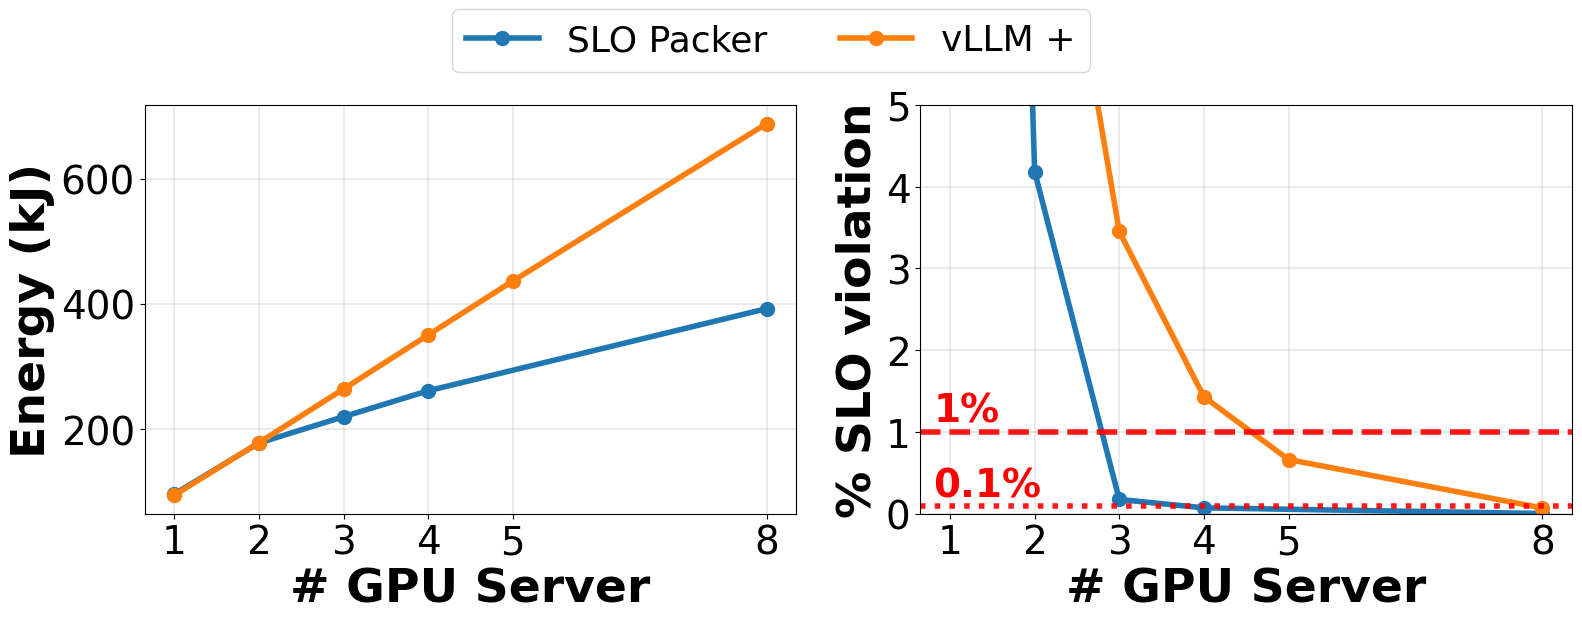

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_json(
    'experiments_emulation_new/Qwen-7B_constant_azure_chat_23:azure_chat_23_t0:600_arrival_0.0/results.jsonl',
    lines=True
)
df['relative power'] = df['energy_est'] * df['load_scale'] / 1000
group = df[df['load_scale'] == 1.0]

LABEL_MAP = {
    'atfc / slosserve_1_disagg_4': 'SLO Packer (Disagg)',
    'atfc / slosserve_2': 'SLO Packer (2, Colocated)',
    'atfc / slosserve_1': 'SLO Packer (1, Colocated)',
    'atfc / slosserve': 'SLO Packer',
    'atfc / round_robin': 'SLO Packer (Round Robin)',
    'atfc / slosserve_4': 'SLO Packer (4, Colocated)',
    'atfc / slosserve_5': 'SLO Packer (5, Colocated)',
    'sarathi+ / round_robin': 'vLLM +',
    'sarathi+ / round_robin-1-disagg-4': 'vLLM + (Disagg)'
}

feature = 'n_device'
keep_labels = {'SLO Packer', 'vLLM +'}

# Slide-friendly typography
plt.rcParams.update({
    "font.size": 26,
    "axes.labelsize": 34,
    "axes.titlesize": 34,
    "xtick.labelsize": 28,
    "ytick.labelsize": 28,
    "legend.fontsize": 26,   # make legend bigger since it's outside
    "lines.linewidth": 4.0,
    "lines.markersize": 10,
})

fig, axes = plt.subplots(1, 2, figsize=(20, 6))  # a bit wider for outside legend

# ---- Left: SLO violation ----
ax0 = axes[1]
handles = []
labels = []

for (sched, route), sub in group.groupby(['scheduling_policy', 'routing_policy']):
    key = f"{sched} / {route}"
    if key not in LABEL_MAP:
        continue
    label = LABEL_MAP[key]
    if label not in keep_labels:
        continue

    sub_sorted = sub.sort_values(feature)
    (line,) = ax0.plot(sub_sorted[feature], sub_sorted['slo_violation_rate'] * 100,
                       marker='o', label=label)

    # collect handles for shared legend (only once per label)
    if label not in labels:
        handles.append(line)
        labels.append(label)

# Red threshold lines (no text)
ax0.axhline(1.0, linestyle='--', linewidth=4.0, color='red', alpha=0.9)
ax0.axhline(0.1, linestyle=':',  linewidth=4.0, color='red', alpha=0.9)

ax0.set_ylabel('% SLO violation', fontweight='bold')
ax0.set_xlabel('# GPU Server', fontweight='bold')
ax0.set_ylim(0, 5)
ax0.grid(True, alpha=0.25, linewidth=1.5)

# ---- Right: Energy ----
ax1 = axes[0]
for (sched, route), sub in group.groupby(['scheduling_policy', 'routing_policy']):
    key = f"{sched} / {route}"
    if key not in LABEL_MAP:
        continue
    label = LABEL_MAP[key]
    if label not in keep_labels:
        continue

    sub_sorted = sub.sort_values(feature)
    ax1.plot(sub_sorted[feature], sub_sorted['relative power'], marker='o', label=label)

ax1.set_ylabel('Energy (kJ)', fontweight='bold')
ax1.set_xlabel('# GPU Server', fontweight='bold')
ax1.grid(True, alpha=0.25, linewidth=1.5)

xticks = [1, 2, 3, 4, 5, 8]
for ax in axes:
    ax.set_xticks(xticks)
    ax.set_xticklabels([str(x) for x in xticks])


# ---- Shared legend outside (right) ----
fig.legend(
    handles, labels,
    loc='upper center',
    bbox_to_anchor=(0.4, 1.10),
    ncol=2,              # set 1/2/3 depending on how wide you want it
    frameon=True,
    fontsize = 
)


x_left, x_right = ax0.get_xlim()
x_text = x_left + 0.02 * (x_right - x_left)

ax0.text(x_text, 1.0 * 1.03,  "1%",   color="red",
         fontsize=28, fontweight="bold", va="bottom", ha="left")
ax0.text(x_text, 0.1 * 1.10,  "0.1%", color="red",
         fontsize=28, fontweight="bold", va="bottom", ha="left")

# leave room on the right for legend
plt.tight_layout(rect=[0, 0, 0.82, 1])
plt.show()

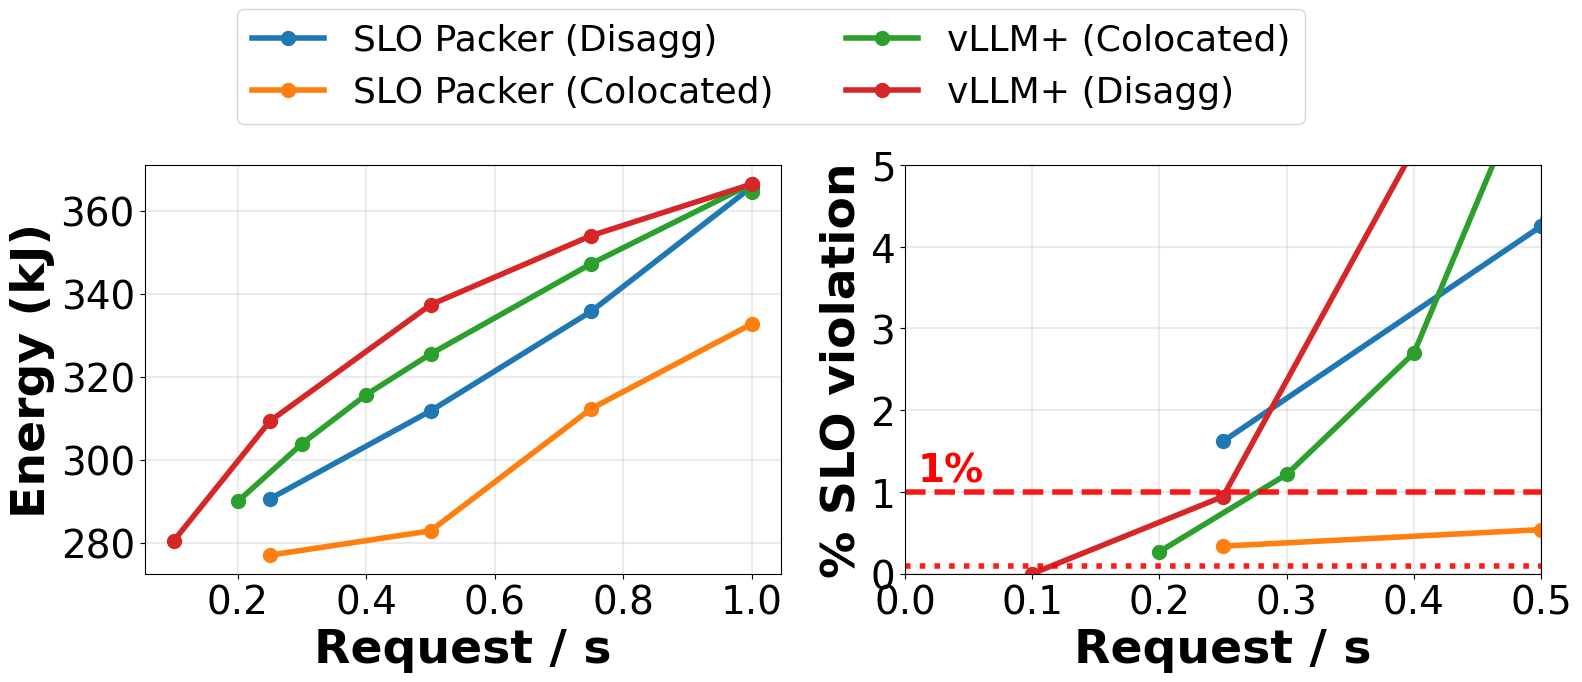

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_json(
    'experiments_emulation_new/Qwen-7B_constant_azure_code_23:azure_code_23_t0:600_arrival_0.0/results.jsonl',
    lines=True
)
df['relative power'] = df['energy_est'] * df['load_scale'] / 1000
group = df[df['n_device'] == 8]

LABEL_MAP = {
    'atfc / slosserve_1_disagg_4': 'SLO Packer (Disagg)',
    'atfc / slosserve_2': 'SLO Packer (Colocated)',
    'atfc / slosserve_1': 'SLO Packer (1, Colocated)',
    'atfc / slosserve': 'SLO Packer (2, Colocated)',
    'atfc / round_robin': 'SLO Packer (Round Robin)',
    'atfc / slosserve_4': 'SLO Packer (4, Colocated)',
    'atfc / slosserve_5': 'SLO Packer (5, Colocated)',
    'sarathi+ / round_robin': 'vLLM+ (Colocated)',
    'sarathi+ / round_robin-1-disagg-4': 'vLLM+ (Disagg)'
}

feature = 'load_scale'
keep_labels = {'SLO Packer (Colocated)', 'SLO Packer (Disagg)', 'vLLM+ (Colocated)', 'vLLM+ (Disagg)'}

# Slide-friendly typography
plt.rcParams.update({
    "font.size": 26,
    "axes.labelsize": 34,
    "axes.titlesize": 34,
    "xtick.labelsize": 28,
    "ytick.labelsize": 28,
    "legend.fontsize": 26,   # make legend bigger since it's outside
    "lines.linewidth": 4.0,
    "lines.markersize": 10,
})

fig, axes = plt.subplots(1, 2, figsize=(20, 6))  # a bit wider for outside legend

# ---- Left: SLO violation ----
ax0 = axes[1]
handles = []
labels = []

for (sched, route), sub in group.groupby(['scheduling_policy', 'routing_policy']):
    key = f"{sched} / {route}"
    if key not in LABEL_MAP:
        continue
    label = LABEL_MAP[key]
    if label not in keep_labels:
        continue

    sub_sorted = sub.sort_values(feature)
    (line,) = ax0.plot(sub_sorted[feature], sub_sorted['slo_violation_rate'] * 100,
                       marker='o', label=label)

    # collect handles for shared legend (only once per label)
    if label not in labels:
        handles.append(line)
        labels.append(label)

# Red threshold lines (no text)
ax0.axhline(1.0, linestyle='--', linewidth=4.0, color='red', alpha=0.9)
ax0.axhline(0.1, linestyle=':',  linewidth=4.0, color='red', alpha=0.9)

ax0.set_ylabel('% SLO violation', fontweight='bold')
ax0.set_xlabel('Request / s', fontweight='bold')
ax0.set_ylim(0, 5)
ax0.set_xlim(0, 2.0)
ax0.grid(True, alpha=0.25, linewidth=1.5)

# ---- Right: Energy ----
ax1 = axes[0]
for (sched, route), sub in group.groupby(['scheduling_policy', 'routing_policy']):
    key = f"{sched} / {route}"
    if key not in LABEL_MAP:
        continue
    label = LABEL_MAP[key]
    if label not in keep_labels:
        continue

    sub_sorted = sub.sort_values(feature)
    ax1.plot(sub_sorted[feature], sub_sorted['relative power'], marker='o', label=label)

ax1.set_ylabel('Energy (kJ)', fontweight='bold')
ax1.set_xlabel('Request / s', fontweight='bold')
ax1.grid(True, alpha=0.25, linewidth=1.5)

# ---- Shared legend outside (right) ----
fig.legend(
    handles, labels,
    loc='upper center',
    bbox_to_anchor=(0.4, 1.20),
    ncol=2,              # set 1/2/3 depending on how wide you want it
    frameon=True
)

ax0.set_xlim(0, 0.5)

x_left, x_right = ax0.get_xlim()
x_text = x_left + 0.02 * (x_right - x_left)

ax0.text(x_text, 1.0 * 1.03,  "1%",   color="red",
         fontsize=28, fontweight="bold", va="bottom", ha="left")
# ax0.text(x_text, 0.1 * 1.10,  "0.1%", color="red",
#          fontsize=28, fontweight="bold", va="bottom", ha="left")

# leave room on the right for legend
plt.tight_layout(rect=[0, 0, 0.82, 1])
plt.show()

In [ ]:
df = plot('experiments_emulation/Qwen-7B_constant_azure_code_23:azure_code_23_t0:600_arrival_0.0/results.jsonl')

# plot('experiments_emulation/Qwen-7B_constant_azure_chat_23:azure_chat_23_t0:600_arrival_0.0/results.jsonl')

/tmp/ipykernel_2393217/3328572535.py:2: FutureWarning: Passing literal json to 'read_json' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  df = pd.read_json(event_file, lines=True)


ValueError: Expected object or value

,load_scale,rps,n_device,scheduling_policy,routing_policy,profit,ttft_slo_scale,slo_tpot,slo_violation_rate,perf_model_err,...,1_active (%),0_active (%),3_active (%),4_active (%),5_active (%),2_active (%),6_active (%),7_active (%),8_active (%),relative power
0,1,4.778562,8,sarathi+,round_robin,0,5,0.05,0.002790,1,...,0.004285,0.003626,0.004944,0.011206,0.017139,0.000989,0.044825,0.163151,0.749835,688179.70
1,1,4.778562,8,atfc,slosserve_2,0,5,0.05,0.002442,1,...,0.005265,0.002632,0.136887,0.040145,0.014808,0.798618,0.001645,NaN,NaN,393421.45
2,2,9.557123,8,sarathi+,round_robin,0,5,0.05,0.012208,1,...,0.009753,NaN,0.001951,0.002601,0.001951,0.001300,0.006502,0.019506,0.956437,707746.70
3,2,9.557123,8,atfc,slosserve_2,0,5,0.05,0.026857,1,...,0.013436,NaN,0.051823,0.311580,0.397953,0.071017,0.132438,0.021753,NaN,540909.10
4,1,4.778562,8,atfc,slosserve_1_disagg_4,0,5,0.05,0.004883,1,...,0.016776,0.003618,0.034539,0.277303,0.454934,0.017763,0.158553,0.030921,0.005592,573333.10
5,3,14.335685,8,sarathi+,round_robin,0,5,0.05,0.069062,1,...,0.010506,NaN,0.002865,0.001910,0.004776,0.000955,0.000955,0.004776,0.973257,729901.95
6,3,14.335685,8,atfc,slosserve_2,0,5,0.05,0.551099,1,...,0.026774,NaN,0.009371,0.036814,0.030790,0.046854,0.012718,0.836680,NaN,932442.15
7,4,19.114246,8,atfc,slosserve_2,0,5,0.05,0.937217,1,...,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,425847.20
8,2,9.557123,8,atfc,slosserve_1_disagg_4,0,5,0.05,0.633066,1,...,0.194502,0.106206,0.056227,0.097043,0.275718,0.118701,0.107039,0.031237,0.013328,798150.60
9,1,4.778562,8,sarathi+,round_robin-1-disagg-4,0,5,0.05,0.008720,1,...,0.004283,0.003624,0.012521,0.211203,0.317298,0.002306,0.233278,0.139044,0.076442,669972.40


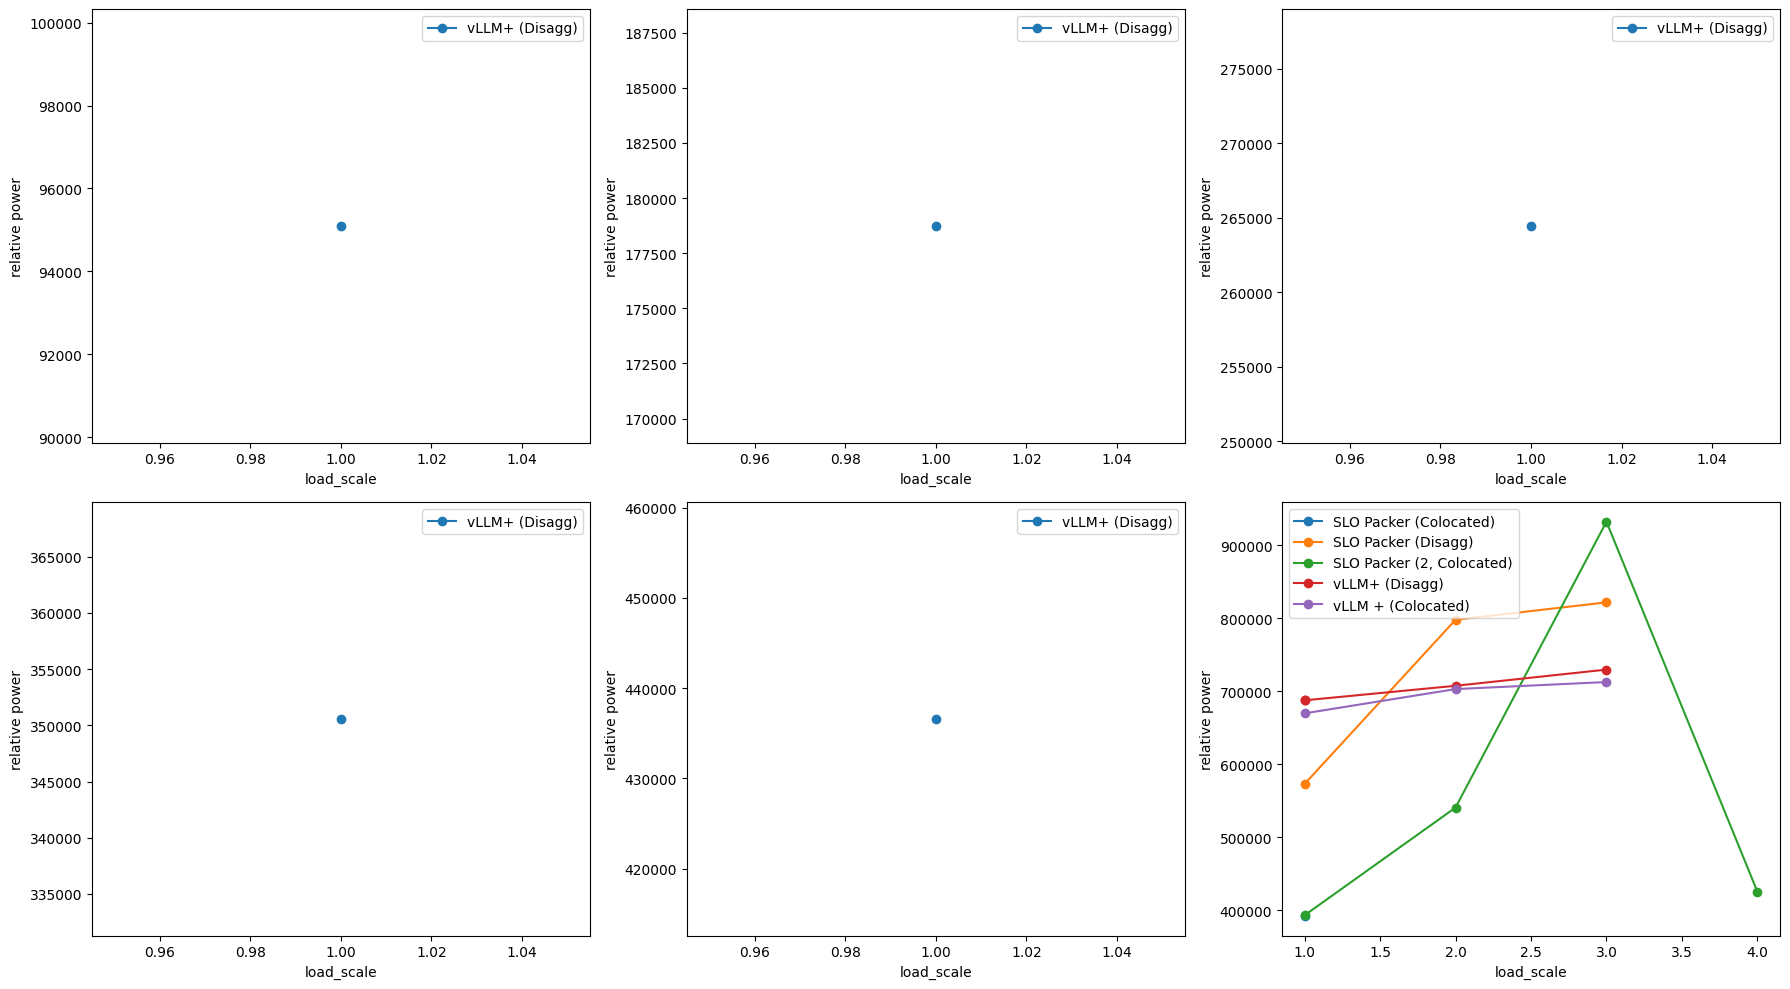

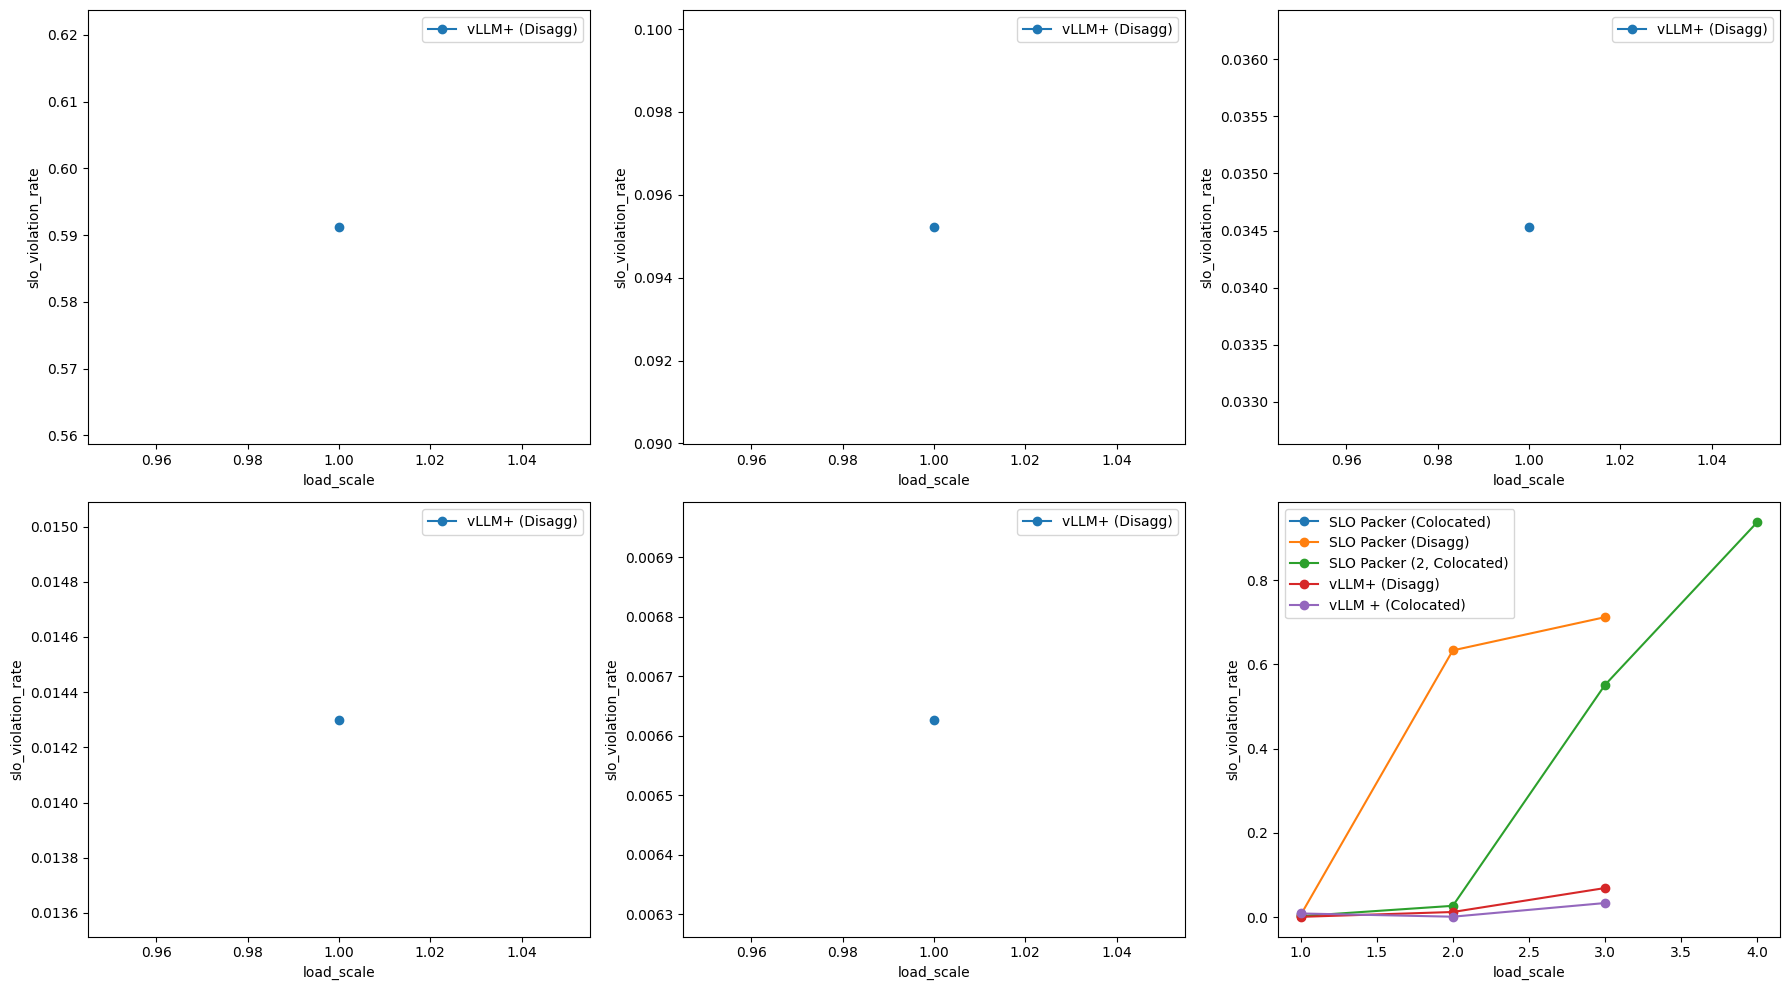

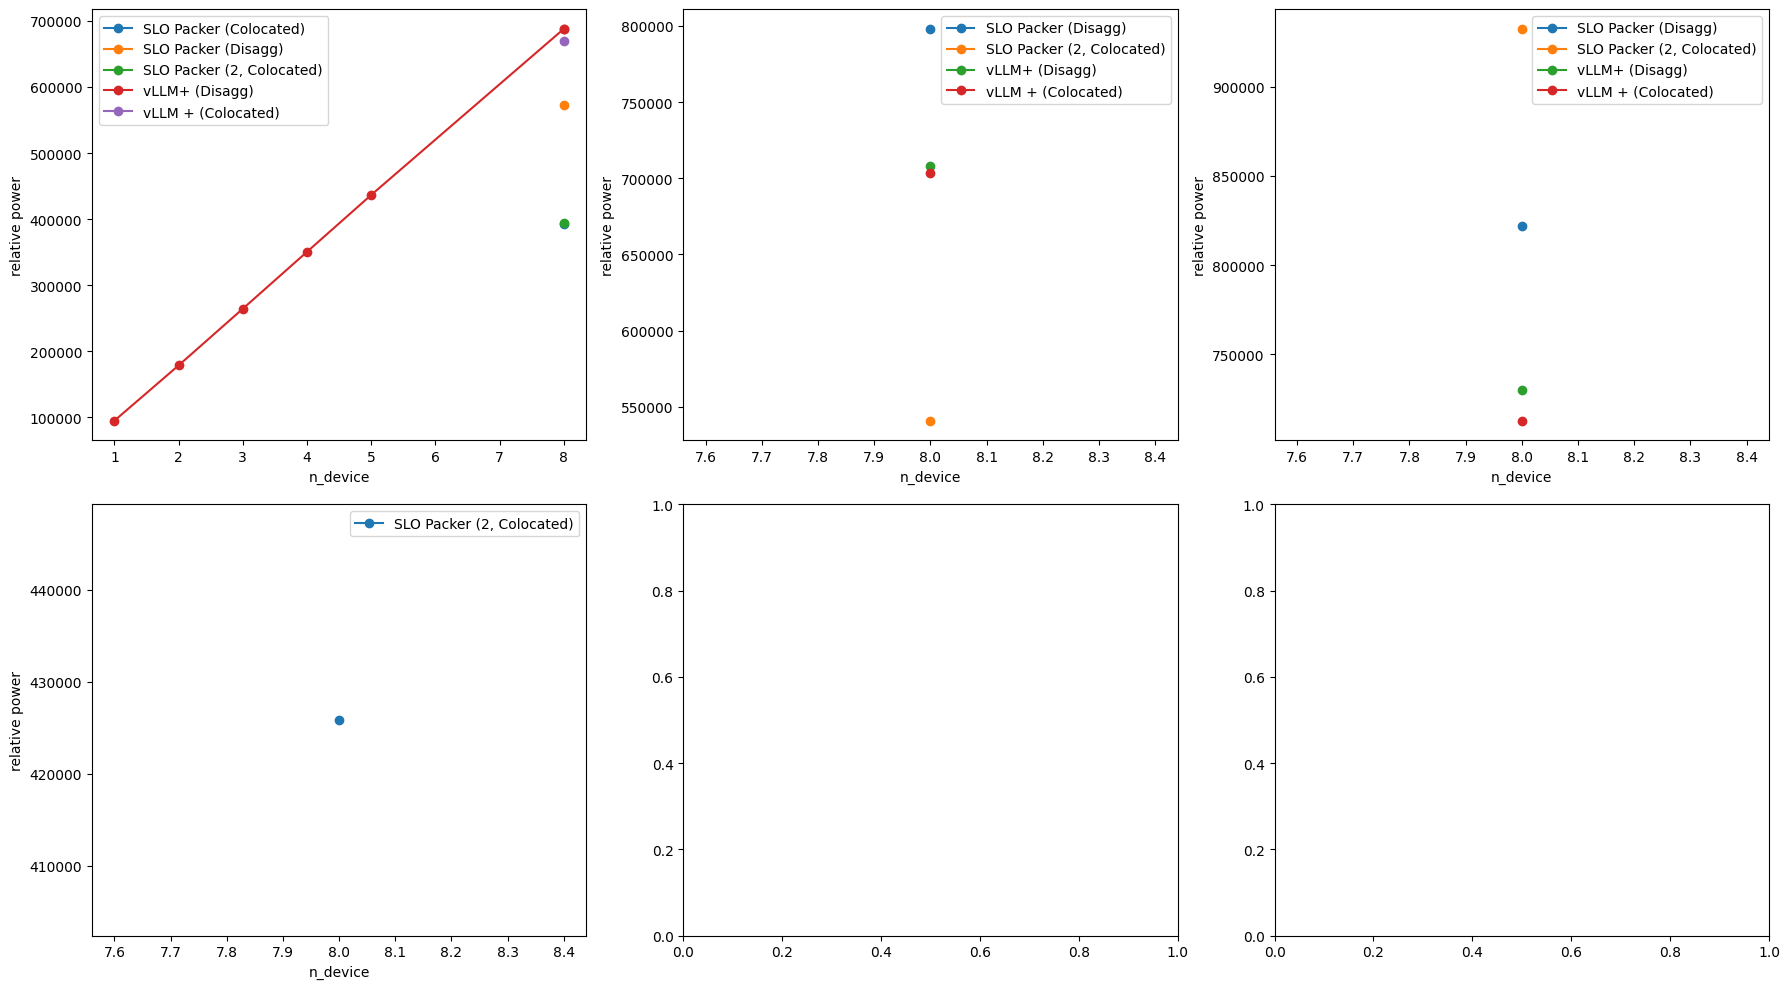

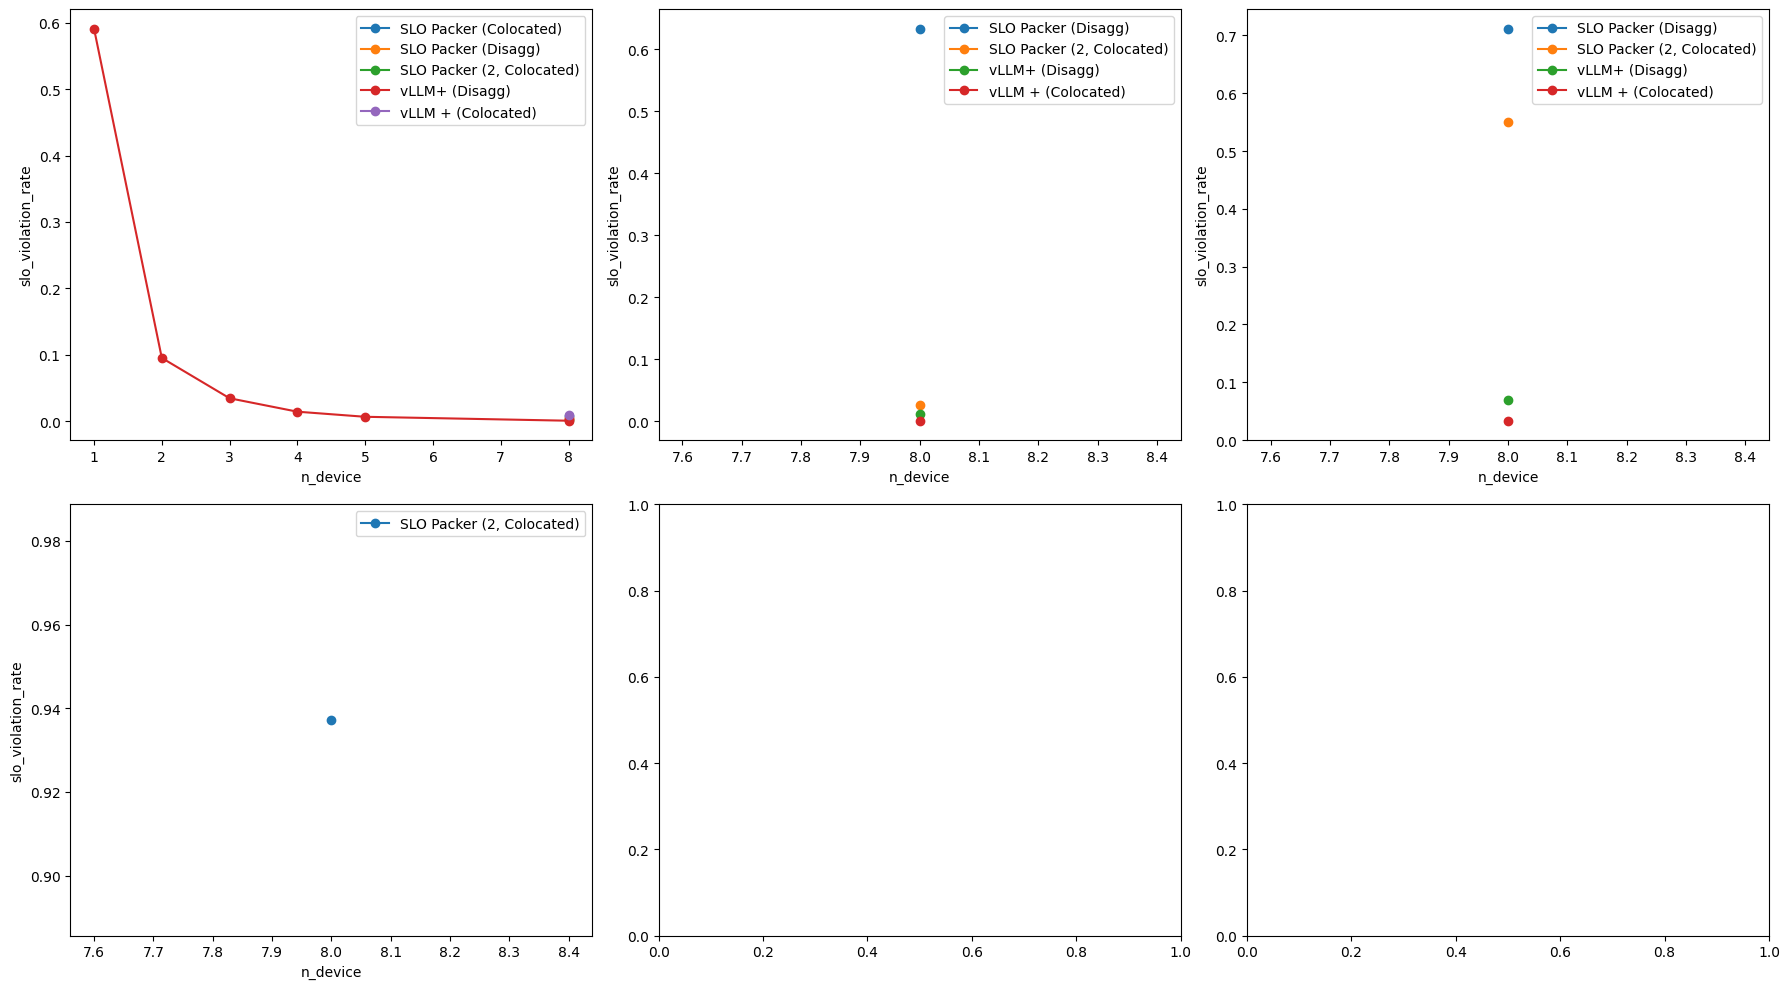

In [6]:
plot('experiments_emulation/Qwen-7B_constant_azure_chat_23:azure_chat_23_t0:600_arrival_0.0/results.jsonl')

In [26]:
subdf = df[df['load_scale'] == 0.5]
subdf['event_file'].tolist()

['experiments_emulation/Qwen-7B_constant_azure_code_23:azure_code_23_t0:600_arrival_0.0/sarathi+_round_robin_0.5_8_arrival_5.0_0.05_asap.events.jsonl',
 'experiments_emulation/Qwen-7B_constant_azure_code_23:azure_code_23_t0:600_arrival_0.0/atfc_slosserve_2_0.5_8_arrival_5.0_0.05_asap.events.jsonl',
 'experiments_emulation/Qwen-7B_constant_azure_code_23:azure_code_23_t0:600_arrival_0.0/atfc_slosserve_1_disagg_4_0.5_8_arrival_5.0_0.05_asap.events.jsonl',
 'experiments_emulation/Qwen-7B_constant_azure_code_23:azure_code_23_t0:600_arrival_0.0/sarathi+_round_robin-1-disagg-4_0.5_8_arrival_5.0_0.05_asap.events.jsonl']

In [ ]:
from motivation.events_analysis import draw_energy_comparison


vLLM+ (Colocated) average  1.4357446808510639 devices
SLO Packer (Colocated) average  0.8509369676320273 devices
SLO Packer (Disagg) average  1.1665250637213254 devices
vLLM+ (Disagg) average  1.6652470187393527 devices
all_energies {'vLLM+ (Colocated)': np.float64(554.0296170212766), 'SLO Packer (Colocated)': np.float64(501.3839011925042), 'SLO Packer (Disagg)': np.float64(529.7535683942226), 'vLLM+ (Disagg)': np.float64(574.7037052810903)}
saved to energy_comparison-None.png
saved to energy_distr-None.png


TypeError: cannot unpack non-iterable NoneType object

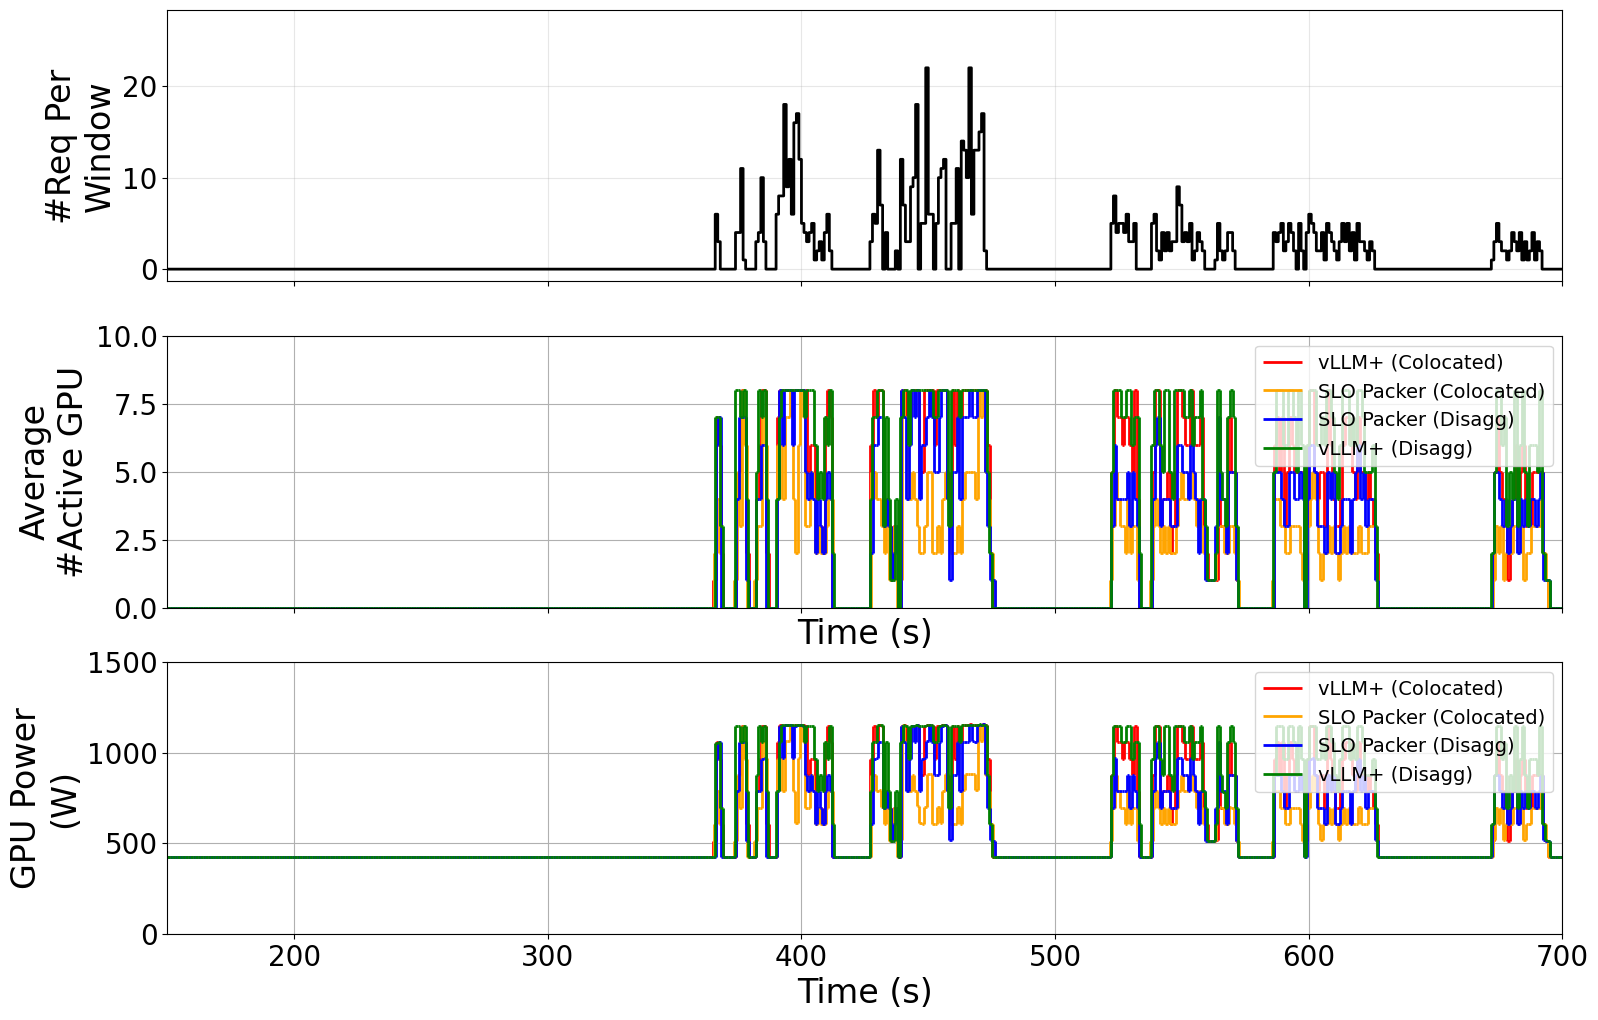

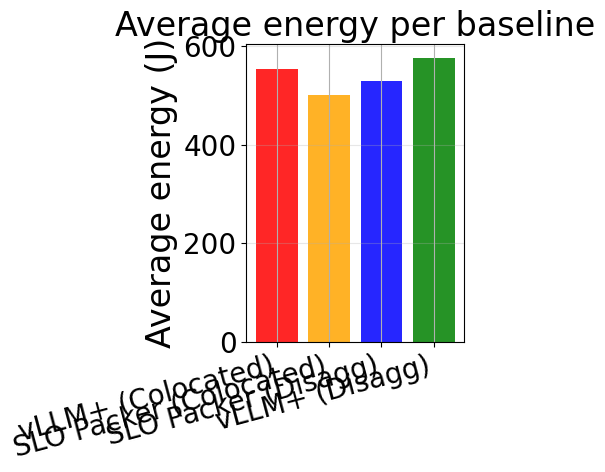

In [ ]:

fig, axes = draw_energy_comparison(
    event_files = [('vLLM+ (Colocated)', 'experiments_emulation/Qwen-7B_constant_azure_code_23:azure_code_23_t0:600_arrival_0.0/sarathi+_round_robin_0.5_8_arrival_5.0_0.05_asap.events.jsonl', 8, 'red'),
                ('SLO Packer (Colocated)', 'experiments_emulation/Qwen-7B_constant_azure_code_23:azure_code_23_t0:600_arrival_0.0/atfc_slosserve_2_0.5_8_arrival_5.0_0.05_asap.events.jsonl', 8, 'orange'),
 ('SLO Packer (Disagg)', 'experiments_emulation/Qwen-7B_constant_azure_code_23:azure_code_23_t0:600_arrival_0.0/atfc_slosserve_1_disagg_4_0.5_8_arrival_5.0_0.05_asap.events.jsonl', 8, 'blue'),
 ('vLLM+ (Disagg)', 'experiments_emulation/Qwen-7B_constant_azure_code_23:azure_code_23_t0:600_arrival_0.0/sarathi+_round_robin-1-disagg-4_0.5_8_arrival_5.0_0.05_asap.events.jsonl', 8, 'green')],
    # [
    #     ('Baseline (8 Servers)', 'experiments_mock/Qwen-7B_constant_sharegpt_code:azure_code_23_3978:4500_anytime_0.0/vllm_round_robin_1.0_8_anytime_5.0_0.05.events.jsonl', 8, 'red'),
    #     # ('Baseline (8 Servers)', 'experiments_mock/Qwen-7B_constant_sharegpt_code:azure_code_23_3978:4600_anytime_0.0/sarathi_round_robin_1.0_8_anytime_5.0_0.05.events.jsonl', 8, 'orange'),
    #     # ('RR + SLOsServe (4, 100%)', 'experiments_mock/Qwen-7B_constant_sharegpt_code:azure_code_23_3978:4500_anytime_0.0/slosserve-edf_round_robin_1.0_4_anytime_5.0_0.05.events.jsonl', 4, 'orange'),
    #     # ('LC (w/o Pre. Adm.) + SLOsServe  (8, 70.8%)', 'experiments_mock/Qwen-7B_constant_sharegpt_code:azure_code_23_3978:4500_anytime_0.0/slosserve-edf_auto_scaling_resch-all_chat-1.0_1.0_8_anytime_5.0_0.05.events.jsonl', 8, 'green'),
    #     # ('LC (Pre. Adm) + SLOsServe  (8, 93.8%)', 'experiments_mock/Qwen-7B_constant_sharegpt_code:azure_code_23_3978:4500_anytime_0.0/slosserve-edf_auto_scaling_resch-all_chat-0.05_1.0_8_anytime_5.0_0.05.events.jsonl', 8, 'green'),
    #     ('SLOsServe (4 Servers)', 'experiments_mock/Qwen-7B_constant_sharegpt_code:azure_code_23_3978:4600_anytime_0.0/slosserve-edf_auto_scaling_resch-all_chat-1.0_1.0_4_anytime_5.0_0.05.events.jsonl', 4, 'blue')
    # ],
    output_suffix = None
)
for ax in axes:
    axes[0].set_xlim(350, 650)

In [ ]:
df = pd.read_json('experiments_emulation/Qwen-7B_constant_azure_chat_23:azure_chat_23_t0:600_arrival_0.0/results.jsonl', lines=  True)
df

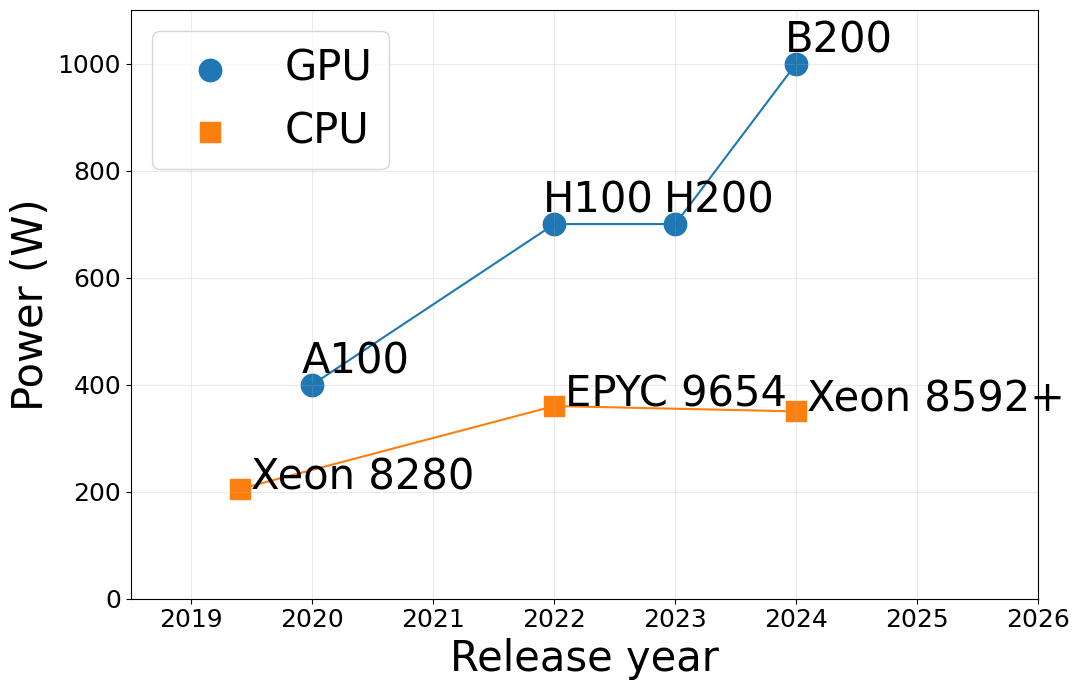

In [31]:
import matplotlib.pyplot as plt

# Data (TDP/TGP in Watts) + release year
gpus = [
    ("A100", 2020, 400),
    ("H100", 2022, 700),
    ("H200", 2023, 700),
    ("B200", 2024, 1000),
]

cpus = [
    # ("Xeon 8180", 2017, 205),
    ("Xeon 8280", 2019.4, 205),
    ("EPYC 9654", 2022, 360),
    # ("Xeon 8490H", 2023, 350),
    ("Xeon 8592+", 2024, 350),  # Q4'23 ~ 2023.8 for spacing
]

# Split for plotting
gpu_years = [y for _, y, _ in gpus]
gpu_watts = [w for _, _, w in gpus]

cpu_years = [y for _, y, _ in cpus]
cpu_watts = [w for _, _, w in cpus]

plt.figure(figsize=(11, 7))
plt.scatter(gpu_years, gpu_watts, s=260, marker='o', label="GPU")
plt.scatter(cpu_years, cpu_watts, s=220, marker='s', label="CPU")

# Connect points to show "growth" trend (sorted by year)
g_sorted = sorted(zip(gpu_years, gpu_watts))
c_sorted = sorted(zip(cpu_years, cpu_watts))
plt.plot([x for x,_ in g_sorted], [y for _,y in g_sorted])
plt.plot([x for x,_ in c_sorted], [y for _,y in c_sorted])

# Annotations
for name, year, watts in gpus:
    plt.annotate(f"{name}", (year, watts),
                 textcoords="offset points", xytext=(-8, 8), ha='left', fontsize=30)
for name, year, watts in cpus:
    plt.annotate(f"{name}", (year, watts),
                 textcoords="offset points", xytext=(8, 0), ha='left', fontsize=30)

plt.xlabel("Release year", fontsize=30)
plt.ylabel("Power (W)", fontsize=30)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.xlim(2018.5, 2026)
plt.ylim(0, 1100)
plt.legend(fontsize=30, loc="upper left")
plt.grid(True, alpha=0.25)

plt.tight_layout()

# out_png = "/mnt/data/power_vs_time_gpu_cpu.png"
# out_pdf = "/mnt/data/power_vs_time_gpu_cpu.pdf"
# plt.savefig(out_png, dpi=200, bbox_inches="tight")
# plt.savefig(out_pdf, bbox_inches="tight")
# out_png, out_pdf
